In [1]:
import torch
import json
import jsonlines

In [2]:
from scipy.sparse import load_npz

In [3]:
B = torch.load("results/interpret_sae/combined/1/word_emission_probabilities.pt", map_location="cpu")["B"]
theta = load_npz("results/interpret_sae/combined/1/theta_csr.npz")
print(f"B shape: {B.shape}, theta shape: {theta.shape}")

B shape: torch.Size([24576, 5000]), theta shape: (30217175, 24576)


In [4]:
import numpy as np

theta = theta.astype(np.float32)

In [5]:
from tqdm.notebook import tqdm

captions_by_index = dict()

with jsonlines.open("data/application/inspect_image_datasets/combined/captions.jsonl") as reader:
    for i, line in tqdm(enumerate(reader)):
        captions_by_index[i] = line["document"]

0it [00:00, ?it/s]

In [6]:
import json

with open("data/application/inspect_image_datasets/combined/bow/5000_5_meta.json", "r") as f:
    bow_data = json.load(f)

In [7]:
import random

line = random.randint(0, theta.shape[0]-1)

caption = captions_by_index[line]
print(caption)
print()

theta_row = theta.getrow(line).toarray().flatten()
# Get top 10 features with highest probabilities
top_features = theta_row.argsort()[-30:][::-1].tolist()

for feature in top_features:
    top_words = B[feature, :].argsort()[-5:].flatten().tolist()
    top_words = top_words[::-1]
    top_words_probs = B[feature, top_words].flatten().tolist()
    top_words = [f"{bow_data['vocab']['id2token'][word]}" for i, word in enumerate(top_words)]
    top_words_str = ", ".join(top_words)
    print(f"Feature {feature} ({theta_row[feature]:.4f}): {top_words_str}")

A serene natural landscape unfolds under a clear, bright sky, characterized by a dominant palette of lush greens, deep browns, and the white froth of cascading water. The central focus is a powerful waterfall, its water plunging over dark, rugged rocks, creating a misty veil at the base. Surrounding the waterfall are slender birch trees with white bark and sparse green foliage, their branches reaching out towards the water. The foreground is a carpet of vibrant green moss and grass, interspersed with small shrubs and fallen branches. In the background, a dense forest of tall, green trees stretches across the horizon, adding depth to the scene. Fine details include the rough texture of the rocks, the smooth, glistening surface of the water, and the delicate patterns of the birch bark. The composition is wide and expansive, capturing the waterfall's dynamic flow and the tranquil, untouched beauty of the surrounding wilderness, with a perspective that emphasizes the grandeur and scale of 

In [8]:
import torch

feature_probabilities = torch.load("results/interpret_sae/combined/1/feature_probabilities.pt")
word_emission_probabilities = torch.load("results/interpret_sae/combined/1/word_emission_probabilities.pt")

In [9]:
import gensim.downloader as api
import os

embeddings = api.load("word2vec-google-news-300")

In [10]:
mean_embedding = embeddings.get_mean_vector(embeddings.key_to_index.keys())

In [11]:
idx2lemma = bow_data["vocab"]["id2token"]

In [12]:
valid_feature_mask = feature_probabilities["theta_avg"] > 0
valid_feature_idx = valid_feature_mask.nonzero().squeeze(1)

B = word_emission_probabilities["B"]
B = B[valid_feature_mask]

In [13]:
def sparsify_and_renormalize(input_tensor: torch.Tensor, tau: float = 0.9) -> torch.Tensor:
    """
    Transforms a tensor by keeping only the n largest entries per row and renormalizing.

    For each row in the input tensor, this function determines the smallest number of
    largest entries, n, whose sum is greater than a threshold `tau`. It then sets all
    other entries in that row to zero and renormalizes the row so that its elements
    sum to 1.

    Args:
        input_tensor (torch.Tensor): A K x V tensor with non-negative entries where each
                                     row sums to 1.
        tau (float, optional): The cumulative sum threshold for determining n.
                               Defaults to 0.9.

    Returns:
        torch.Tensor: The transformed K x V tensor where only the n largest entries
                      per row are non-zero, and each row is renormalized to sum to 1.
    """
    if not isinstance(input_tensor, torch.Tensor):
        raise TypeError(f"Input must be a torch.Tensor, but got {type(input_tensor)}")
    if input_tensor.dim() != 2:
        raise ValueError(f"Input tensor must be 2-dimensional, but got {input_tensor.dim()} dimensions")
    if not (0 < tau < 1):
        print(f"Warning: tau is {tau}, but it's typically expected to be between 0 and 1.")

    # Get the shape of the tensor
    K, V = input_tensor.shape
    device = input_tensor.device

    # --- Step 1: Sort the tensor's values in descending order along each row ---
    # We keep the original indices to reconstruct the tensor later.
    sorted_values, sorted_indices = torch.sort(input_tensor, dim=-1, descending=True)

    # --- Step 2: Calculate the cumulative sum of the sorted values for each row ---
    cumulative_sums = torch.cumsum(sorted_values, dim=-1)

    # --- Step 3: Determine n for each row ---
    # n is the minimum number of elements whose cumulative sum exceeds tau.
    # We find the index of the first element in each row that is > tau.
    # The number of elements to keep (n) is that index + 1.
    n_elements = torch.argmax((cumulative_sums > tau).int(), dim=-1) + 1

    # Edge case: If for some row, the total sum (which is 1.0) is not > tau,
    # argmax will return 0, making n_elements=1. A more robust behavior is to
    # keep all elements if the condition is never met.
    # This happens if tau >= 1.0
    never_exceeds_tau = (cumulative_sums > tau).sum(dim=-1) == 0
    n_elements[never_exceeds_tau] = V

    # --- Step 4: Create a mask to keep only the top n elements ---
    # We create a boolean mask based on the sorted tensor's shape.
    arange_tensor = torch.arange(V, device=device).expand(K, -1)
    mask_sorted = arange_tensor < n_elements.unsqueeze(-1)

    # --- Step 5: Un-sort the mask to match the original tensor's structure ---
    # We use scatter to place the `True` values from `mask_sorted` into a new
    # mask at the positions specified by `sorted_indices`.
    final_mask = torch.zeros_like(input_tensor, dtype=torch.bool)
    final_mask.scatter_(dim=1, index=sorted_indices, src=mask_sorted)

    # --- Step 6: Apply the mask to the original tensor ---
    # This sets all elements not in the top n to zero.
    transformed_tensor = input_tensor * final_mask

    # --- Step 7: Renormalize each row to sum to 1 ---
    row_sums = torch.sum(transformed_tensor, dim=-1, keepdim=True)

    # Add a small epsilon to the denominator to prevent division by zero,
    # though this is unlikely if the input tensor has positive entries.
    epsilon = 1e-9
    renormalized_tensor = transformed_tensor / (row_sums + epsilon)

    return renormalized_tensor

In [14]:
import numpy as np


lemmas = idx2lemma
lemma_embeddings = []
for lemma in lemmas:
    try:
        lemma_embeddings.append(embeddings[lemma])
    except KeyError:
        lemma_embeddings.append(mean_embedding)

lemma_embeddings = np.stack(lemma_embeddings)
lemma_embeddings = torch.from_numpy(lemma_embeddings).float()

In [15]:
topic_embeddings = sparsify_and_renormalize(B, tau=0.9) @ lemma_embeddings
print(topic_embeddings.shape)

torch.Size([24514, 300])


In [16]:
weights = feature_probabilities["theta_avg"][valid_feature_idx]

In [17]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.spatial.distance import cdist


reprs = topic_embeddings.cpu().numpy()
#reprs = word_emission_probabilities["B"][valid_feature_idx].cpu().numpy()
#reprs = decoder_weights

kmeans = KMeans(n_clusters=100, random_state=42)
clusters = kmeans.fit_transform(reprs, sample_weight=weights.cpu().numpy())

In [18]:
from collections import defaultdict
import pandas as pd
from tqdm.notebook import tqdm


def get_cluster_overview(theta):
    clusters = defaultdict(list)
    cluster_probs = defaultdict(list)
    cluster_words = defaultdict(list)

    total = theta.shape[0]

    for k, label in enumerate(kmeans.labels_.tolist()):
        clusters[label].append(valid_feature_idx[k].item())
        cluster_probs[label].append(weights[k].item())

    for k, v in sorted(clusters.items(), key=lambda x: len(x[1]), reverse=True):
        avg_probs = word_emission_probabilities["B"][v, :]
        avg_thetas = feature_probabilities["theta_avg"][v].flatten()
        avg_probs = (avg_probs * avg_thetas.unsqueeze(1)).sum(dim=0) / avg_thetas.sum()
        # Find smallest n so that the sum of the probabilities is greater than 0.9
        n = 0
        sorted_avg_probs = sorted(avg_probs.tolist(), reverse=True)
        while sum(sorted_avg_probs[:n]) < 0.9:
            n += 1
        top_n_words = torch.argsort(avg_probs, dim=-1, descending=True)[:n]
        top_n_words = [idx2lemma[i.item()] for i in top_n_words]
        cluster_words[k] = ", ".join(top_n_words)

    cluster_probs = {k: np.sum(v).item() for k, v in cluster_probs.items()}

    feature_idx_to_cluster = {
        valid_feature_idx[k].item(): label for k, label in enumerate(kmeans.labels_.tolist())
    }

    cluster_counts = defaultdict(set)
    for idx, feature_idx in tqdm(zip(*theta.nonzero()), total=theta.nnz):
        idx = idx.item()
        feature_idx = feature_idx.item()
        if feature_idx in feature_idx_to_cluster:
            cluster_counts[feature_idx_to_cluster[feature_idx]].add(idx)

    cluster_records = []
    for k in clusters.keys():
        cluster_records.append({
            "cluster_id": k,
            "cluster_size": len(clusters[k]),
            "cluster_prob": cluster_probs[k],
            "cluster_words": cluster_words[k],
            "cluster_ratio": len(cluster_counts[k]) / total
        })

    cluster_df = pd.DataFrame(cluster_records)
    return cluster_df

In [19]:
cluster_df_cc3m = get_cluster_overview(theta[:2905954])
cluster_df_cc12m = get_cluster_overview(theta[2905954:13874493])
cluster_df_yfcc = get_cluster_overview(theta[13874494:28936008])
cluster_df_imagenet = get_cluster_overview(theta[28936008:])

  0%|          | 0/97049039 [00:00<?, ?it/s]

  0%|          | 0/371507020 [00:00<?, ?it/s]

  0%|          | 0/491643434 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
os.makedirs("results/vision_dataset_composition", exist_ok=True)
cluster_df_cc3m.to_csv("results/vision_dataset_composition/cc3m.csv", index=False)
cluster_df_cc12m.to_csv("results/vision_dataset_composition/cc12m.csv", index=False)
cluster_df_yfcc.to_csv("results/vision_dataset_composition/yfcc.csv", index=False)
cluster_df_imagenet.to_csv("results/vision_dataset_composition/imagenet.csv", index=False)

In [ ]:
cluster_df_cc12m.sort_values(by="cluster_ratio", ascending=False).head(50)

,cluster_id,cluster_size,cluster_prob,cluster_words,cluster_ratio
51,17,44,0.079234,"foreground, natural, perspective, depth, mute,...",0.902436
6,21,1530,0.065158,"clean, plain, design, minimalist, simple, visu...",0.871354
12,55,256,0.044347,"shallow, field, serene, sky, blur, late, depth...",0.657856
19,19,409,0.048651,"group, dress, man, another, engage, hold, wear...",0.641556
40,5,158,0.027727,"warm, illuminate, glow, blur, partially, possi...",0.564781
24,33,503,0.031596,"window, wooden, area, sign, wall, beige, floor...",0.525805
39,89,546,0.029025,"intimate, face, expression, smile, heart, hair...",0.460564
8,7,2932,0.027527,"title, label, number, slide, display, text, ed...",0.456368
14,11,499,0.034438,"shirt, dress, man, hand, short, hair, wear, wo...",0.445839
29,23,768,0.028715,"table, room, wooden, floor, chair, cozy, indoo...",0.396609


In [20]:
import pandas as pd

from collections import defaultdict

In [21]:
cc3m_annotated = pd.read_csv("results/vision_dataset_composition/cc3m_annotated.csv")

In [22]:
cc3m_annotated

,cluster_id,cluster_size,cluster_prob,cluster_words,cluster_ratio,llm_classification,llm_summary
0,1,426,0.015703,"hand, leg, seat, clock, bent, arm, cross, post...",0.362056,concrete,Human Posture
1,58,90,0.009230,"rocky, rock, rugged, mountain, terrain, landsc...",0.095599,concrete,Mountainous Terrain
2,69,524,0.011439,"figure, tattoo, mask, skin, character, face, s...",0.203088,concrete,Character Design
3,4,679,0.009377,"industrial, construction, metal, mechanical, m...",0.095674,concrete,Industrial Construction
4,56,719,0.017560,"illustration, character, monochromatic, photog...",0.286237,abstract,Playful Illustration
...,...,...,...,...,...,...,...
95,93,4,0.001154,"bridge, rail, metal, walkway, river, sturdy, s...",0.019134,concrete,Bridge Structure
96,82,1,0.003542,"green, vibrant, color, vivid, greenish, yellow...",0.121821,abstract,Vibrant Colors
97,47,5,0.000742,"fence, gate, wooden, post, beyond, horizontall...",0.014312,concrete,Rustic Fence
98,45,6,0.001214,"cat, kitten, tabby, fur, feline, whisker, paw,...",0.012797,concrete,Feline Curiosity


In [23]:
cluster_id_to_summary = {row["cluster_id"]: row["llm_summary"] for _, row in cc3m_annotated.iterrows()}
cluster_id_to_mode = {row["cluster_id"]: row["llm_classification"] for _, row in cc3m_annotated.iterrows()}

In [24]:
import numpy as np

cc3m = pd.read_csv("results/vision_dataset_composition/cc3m.csv")
cc12m = pd.read_csv("results/vision_dataset_composition/cc12m.csv")
yfcc = pd.read_csv("results/vision_dataset_composition/yfcc.csv")
imagenet = pd.read_csv("results/vision_dataset_composition/imagenet.csv")

cluster_id_to_ratios = defaultdict(dict)
for _, row in cc3m.iterrows():
    cluster_id_to_ratios[row["cluster_id"]]["cc3m"] = row["cluster_ratio"]
for _, row in cc12m.iterrows():
    cluster_id_to_ratios[row["cluster_id"]]["cc12m"] = row["cluster_ratio"]
for _, row in yfcc.iterrows():
    cluster_id_to_ratios[row["cluster_id"]]["yfcc"] = row["cluster_ratio"]
for _, row in imagenet.iterrows():
    cluster_id_to_ratios[row["cluster_id"]]["imagenet"] = row["cluster_ratio"]

cluster_id_to_ratios_mean = {k: np.array(list(v.values())).mean() for k, v in cluster_id_to_ratios.items()}

In [25]:
concrete_cluster_ids = [cluster_id for cluster_id, mode in cluster_id_to_mode.items() if mode == "concrete"]

In [26]:
concrete_cluster_ids = [cluster_id for cluster_id in concrete_cluster_ids if cluster_id_to_ratios_mean[cluster_id] < 0.4]

In [27]:
sorted_cluster_ids = list(sorted(concrete_cluster_ids, key=lambda x: cluster_id_to_ratios_mean[x], reverse=True))

In [28]:
df = []

for cluster_id in sorted_cluster_ids:
    row = {
        "cluster_id": cluster_id,
        "cc3m_ratio": cluster_id_to_ratios[cluster_id]["cc3m"],
        "cc12m_ratio": cluster_id_to_ratios[cluster_id]["cc12m"],
        "yfcc_ratio": cluster_id_to_ratios[cluster_id]["yfcc"],
        "imagenet_ratio": cluster_id_to_ratios[cluster_id]["imagenet"],
        "llm_summary": cluster_id_to_summary[cluster_id],
    }
    df.append(row)

df = pd.DataFrame(df)

In [29]:
df["variance"] = df.apply(lambda x: np.var([x["cc3m_ratio"], x["cc12m_ratio"], x["yfcc_ratio"], x["imagenet_ratio"]]), axis=1)
df.sort_values(by="variance", ascending=False).head(10)

,cluster_id,cc3m_ratio,cc12m_ratio,yfcc_ratio,imagenet_ratio,llm_summary,variance
5,0,0.238794,0.232787,0.271356,0.449016,Delicate Plant,0.007818
3,10,0.217564,0.294623,0.262271,0.439480,Containers and Packaging,0.006914
7,13,0.323714,0.228960,0.238285,0.101204,Human Interaction,0.006312
21,18,0.076335,0.086549,0.076826,0.259943,Fluffy Animals,0.006094
1,75,0.303323,0.264186,0.447160,0.403031,Lush Landscape,0.005429
17,35,0.082433,0.101626,0.099232,0.248810,Wildlife,0.004523
4,79,0.328731,0.388142,0.246696,0.231623,Text Design,0.004026
9,6,0.189373,0.274098,0.145828,0.113898,Typography and Writing,0.003619
16,44,0.139701,0.103797,0.221689,0.076848,Urban Environment,0.002973
12,30,0.209739,0.139292,0.234158,0.098260,Live Performance,0.002946


In [30]:
df.columns

Index(['cluster_id', 'cc3m_ratio', 'cc12m_ratio', 'yfcc_ratio',
       'imagenet_ratio', 'llm_summary', 'variance'],
      dtype='object')

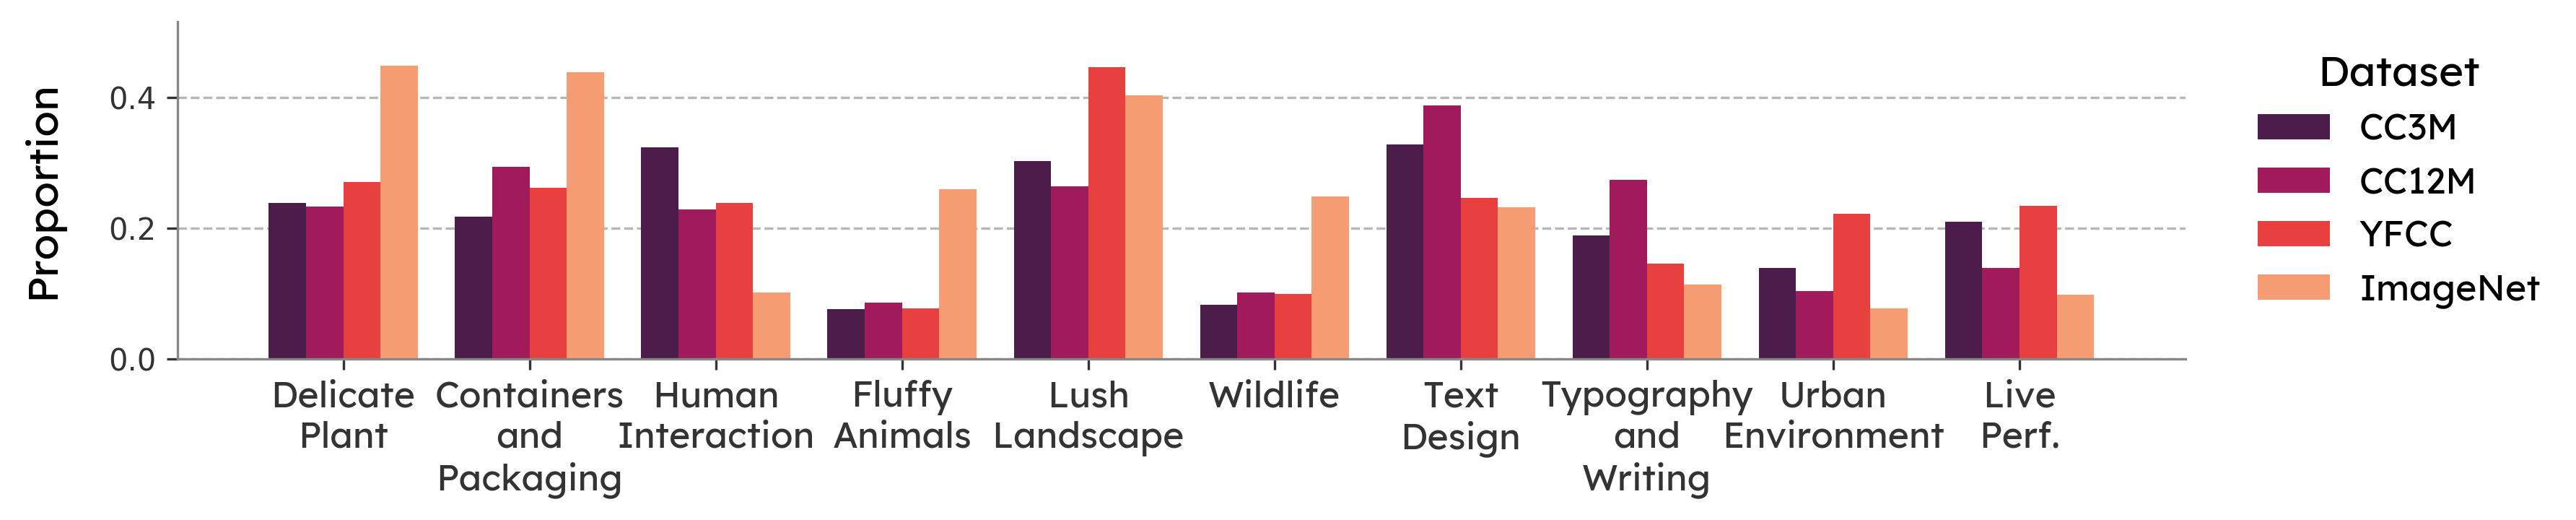

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import seaborn as sns
import matplotlib.font_manager as fm

regular_font_path = 'data/assets/fonts/Lexend-Regular.ttf'
bold_font_path = 'data/assets/fonts/Lexend-Bold.ttf'

lexend_regular = fm.FontProperties(fname=regular_font_path, size=12)
lexend_bold = fm.FontProperties(fname=bold_font_path, size=12)
lexend_title = fm.FontProperties(fname=regular_font_path, size=14)

# 6. Create the DataFrame
df = df.sort_values(by="variance", ascending=False).head(10)

# Convert ratio and other numeric columns to float/int
numeric_cols = ['cluster_id', 'cc3m_ratio', 'cc12m_ratio', 'yfcc_ratio', 'imagenet_ratio', 'variance']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

# --- 2. Plotting Preparation ---

# Get the labels for the x-axis
labels = df['llm_summary']
# Get the data for each of the 4 groups
data_cc3m = df['cc3m_ratio']
data_cc12m = df['cc12m_ratio']
data_yfcc = df['yfcc_ratio']
data_imagenet = df['imagenet_ratio']

# Set up x-axis positions for the groups
x = np.arange(len(labels))  # the label locations
width = 0.2  # the width of the bars
n_groups = 4 # Number of datasets

# Calculate the position for each bar in a group
positions = [
    x - (width * 1.5),
    x - (width * 0.5),
    x + (width * 0.5),
    x + (width * 1.5)
]
data_to_plot = [data_cc3m, data_cc12m, data_yfcc, data_imagenet]
data_labels = ['CC3M', 'CC12M', 'YFCC', 'ImageNet']

# Get a clean color scheme (using 'tab10' colormap)
#colors = plt.cm.get_cmap('tab10', 10)
colors = sns.color_palette("rocket", 4)

# --- 3. Create the Matplotlib Plot ---

# Set a figure size that will accommodate the labels
fig, ax = plt.subplots(figsize=(12, 2.5), dpi=300)

# Add each bar group
for i in range(n_groups):
    ax.bar(
        positions[i], 
        data_to_plot[i], 
        width, 
        label=data_labels[i], 
        color=colors[i]
    )

# --- 4. Style the Plot for a Clean, Scientific Look ---

# Set title and labels with appropriate padding
#ax.set_title('Dataset Ratios by Image Cluster Summary', fontsize=18, pad=20, weight='bold')
ax.set_ylabel('Proportion', fontproperties=lexend_title, labelpad=15)
#ax.set_xlabel('Cluster LLM Summary', fontsize=14, labelpad=15)

# Set the x-axis ticks and labels
ax.set_xticks(x)
labels = labels.str.replace(" ", "\n")
labels = labels.str.replace("Performance", "Perf.")
ax.set_xticklabels(labels, rotation=0, ha='center', fontproperties=lexend_regular)

# Set y-axis limits to give some space at the top
ax.set_ylim(0, df[numeric_cols[1:5]].max().max() * 1.15)

# Add a legend
# We place it outside the plot area to keep the chart clean
ax.legend(
    title='Dataset', 
    prop=lexend_regular, 
    title_fontproperties=lexend_title, 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), 
    frameon=False
)

# Add a horizontal grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#888888')
ax.set_axisbelow(True) # Ensure grid is behind the bars

# Remove the top and right spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

# Set tick colors
ax.tick_params(axis='x', colors='#333333')
ax.tick_params(axis='y', colors='#333333')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/vision_dataset_composition.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.show()
